In [15]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import pickle

In [3]:
with open('../data/pca_data.pkl', 'rb') as f:
      data = pickle.load(f)

data.keys()

dict_keys(['df', 'X', 'X_scaled', 'X_pca', 'pca', 'feature_cols'])

In [4]:
df = data['df']
X = data['X']
X_scaled = data['X_scaled']
X_pca = data['X_pca']
feature_cols = data['feature_cols']

# Cluster on X_scaled

In [5]:
k_range = range(2, 9)
bic_scores = []
sil_scores = []

for k in k_range:
  gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
  labels = gmm.fit_predict(X_scaled)
  bic_scores.append(gmm.bic(X_scaled))
  sil_scores.append(silhouette_score(X_scaled, labels))

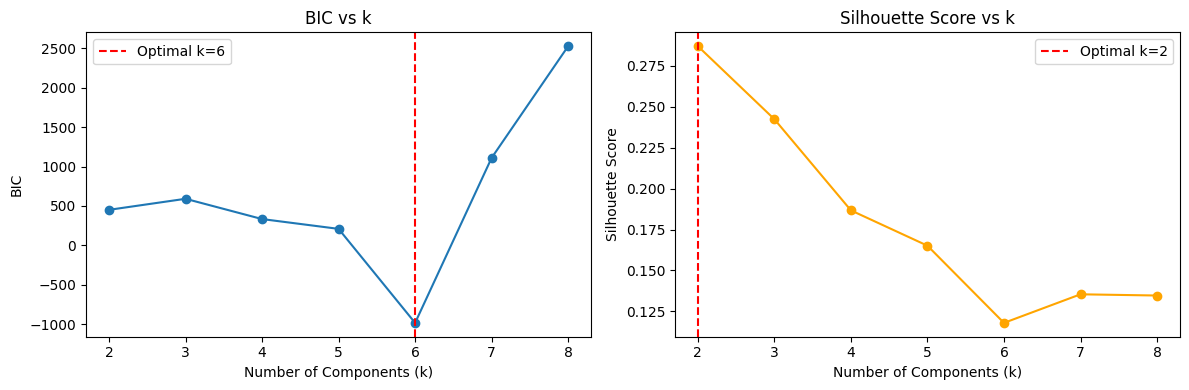

Best k by BIC: 6
Best k by Silhouette: 2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), bic_scores, marker='o')
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC vs k')
axes[0].axvline(k_range[bic_scores.index(min(bic_scores))], color='red', linestyle='--', label=f'Optimal k={k_range[bic_scores.index(min(bic_scores))]}')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].axvline(k_range[sil_scores.index(max(sil_scores))], color='red', linestyle='--', label=f'Optimal k={k_range[sil_scores.index(max(sil_scores))]}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best k by BIC: {k_range[bic_scores.index(min(bic_scores))]}")
print(f"Best k by Silhouette: {k_range[sil_scores.index(max(sil_scores))]}")

# Cluster on X_pca

In [7]:
k_range = range(2, 9)
bic_scores = []
sil_scores = []

for k in k_range:
  gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
  labels = gmm.fit_predict(X_pca)
  bic_scores.append(gmm.bic(X_pca))
  sil_scores.append(silhouette_score(X_pca, labels))

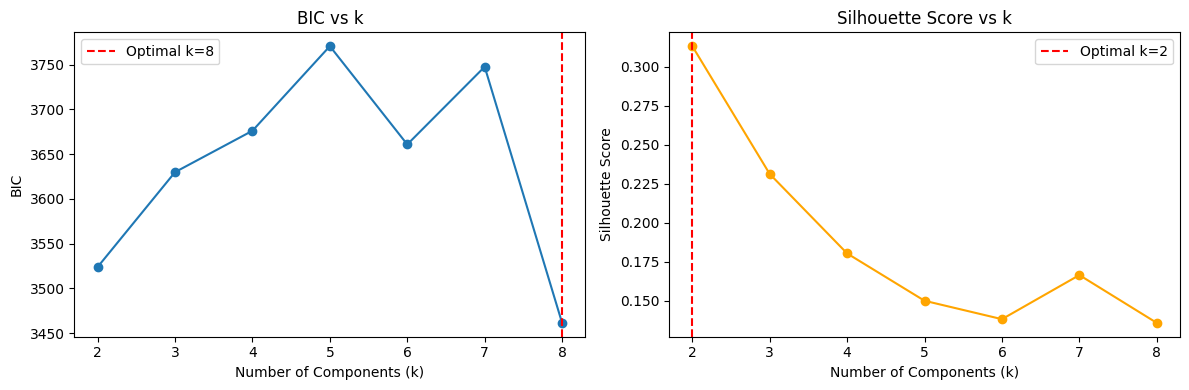

Best k by BIC: 8
Best k by Silhouette: 2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), bic_scores, marker='o')
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC vs k')
axes[0].axvline(k_range[bic_scores.index(min(bic_scores))], color='red', linestyle='--', label=f'Optimal k={k_range[bic_scores.index(min(bic_scores))]}')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].axvline(k_range[sil_scores.index(max(sil_scores))], color='red', linestyle='--', label=f'Optimal k={k_range[sil_scores.index(max(sil_scores))]}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best k by BIC: {k_range[bic_scores.index(min(bic_scores))]}")
print(f"Best k by Silhouette: {k_range[sil_scores.index(max(sil_scores))]}")

In [9]:
# Train gmm with 2 components
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)

In [13]:
X

,RATING_3_0,T_RATING,CT_RATING,ROUND_SWING,DPR,KAST,MULTI_KILL,ADR,KPR,Total_kills,...,ak47_kills,m4a1_kills,m4a1s_kills,deagle_kills,glock_kills,usp_kills,sniper_kills_log,sniper_pct_log,awp_kills_log,ssg08_kills_log
player_id,,,,,,,,,,,,,,,,,,,,,
21167,1.41,1.46,1.38,3.72,0.66,77.8,25.1,94.5,0.90,889,...,514,109,68,38,33,40,2.484907,0.788457,2.484907,0.000000
11893,1.36,1.38,1.35,4.03,0.55,77.6,22.3,85.1,0.86,1053,...,277,81,5,35,40,25,6.091310,3.758872,6.063785,2.564949
19230,1.28,1.17,1.39,3.78,0.59,76.7,20.4,81.0,0.81,823,...,141,28,41,14,41,17,6.200509,4.032469,6.161207,2.995732
21667,1.21,1.17,1.24,1.78,0.68,74.2,19.5,86.0,0.77,1202,...,491,67,253,13,40,55,3.295837,1.163151,3.178054,1.386294
16693,1.20,1.17,1.24,1.45,0.66,76.6,20.0,78.8,0.75,924,...,310,273,4,16,43,35,1.098612,0.182322,1.098612,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20112,0.98,0.93,1.02,-0.27,0.65,72.2,13.0,67.3,0.61,862,...,346,198,67,21,41,46,1.609438,0.336472,1.386294,0.693147
22929,0.94,0.96,0.92,-1.20,0.69,71.6,13.9,68.9,0.62,784,...,385,35,181,7,36,35,1.609438,0.405465,1.609438,0.000000
10096,0.88,0.83,0.93,-1.74,0.69,68.4,11.3,63.0,0.54,674,...,222,134,57,6,25,37,2.484907,0.955511,2.397895,0.693147


In [17]:
# Cluster profile
X_labeled = pd.DataFrame({'player_id': df['player_id'].to_list(), 'cluster': labels})

df_labeled = df.join(
    pl.DataFrame(X_labeled),
    on='player_id',
    how='left'
)

agg_exprs = []
for col in feature_cols:
    agg_exprs += [
        pl.col(col).mean().alias(f'{col}_mean'),
        pl.col(col).std().alias(f'{col}_std'),
        pl.col(col).min().alias(f'{col}_min'),
        pl.col(col).max().alias(f'{col}_max'),
        pl.col(col).median().alias(f'{col}_median'),
    ]

cluster_agg = df_labeled.group_by('cluster').agg(agg_exprs).sort('cluster')
cluster_agg

cluster,RATING_3_0_mean,RATING_3_0_std,RATING_3_0_min,RATING_3_0_max,RATING_3_0_median,T_RATING_mean,T_RATING_std,T_RATING_min,T_RATING_max,T_RATING_median,CT_RATING_mean,CT_RATING_std,CT_RATING_min,CT_RATING_max,CT_RATING_median,ROUND_SWING_mean,ROUND_SWING_std,ROUND_SWING_min,ROUND_SWING_max,ROUND_SWING_median,DPR_mean,DPR_std,DPR_min,DPR_max,DPR_median,KAST_mean,KAST_std,KAST_min,KAST_max,KAST_median,MULTI_KILL_mean,MULTI_KILL_std,MULTI_KILL_min,MULTI_KILL_max,MULTI_KILL_median,ADR_mean,…,m4a1s_kills_max,m4a1s_kills_median,deagle_kills_mean,deagle_kills_std,deagle_kills_min,deagle_kills_max,deagle_kills_median,glock_kills_mean,glock_kills_std,glock_kills_min,glock_kills_max,glock_kills_median,usp_kills_mean,usp_kills_std,usp_kills_min,usp_kills_max,usp_kills_median,sniper_kills_log_mean,sniper_kills_log_std,sniper_kills_log_min,sniper_kills_log_max,sniper_kills_log_median,sniper_pct_log_mean,sniper_pct_log_std,sniper_pct_log_min,sniper_pct_log_max,sniper_pct_log_median,awp_kills_log_mean,awp_kills_log_std,awp_kills_log_min,awp_kills_log_max,awp_kills_log_median,ssg08_kills_log_mean,ssg08_kills_log_std,ssg08_kills_log_min,ssg08_kills_log_max,ssg08_kills_log_median
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1.091163,0.104886,0.9,1.41,1.09,1.072093,0.11791,0.84,1.46,1.06,1.11093,0.111009,0.92,1.39,1.11,0.853023,1.188744,-1.65,4.03,0.79,0.626279,0.049426,0.53,0.72,0.63,73.653488,2.264987,68.8,77.8,73.9,17.297674,2.426588,13.5,25.1,17.2,73.795349,…,307,69.0,17.465116,12.681724,0,67,16.0,41.767442,15.063101,19,83,40.0,48.651163,20.80623,0,86,47.0,3.801133,2.260026,0.0,6.678342,3.295837,2.067302,1.706405,0.0,4.092677,1.386294,3.744065,2.298398,0.0,6.654153,3.295837,1.24149,1.200137,0.0,3.828641,0.693147
1,1.044909,0.08522,0.84,1.21,1.04,1.022182,0.098502,0.79,1.24,1.02,1.066,0.092268,0.9,1.27,1.05,0.107818,0.925426,-2.04,1.88,0.09,0.654364,0.027806,0.6,0.71,0.65,72.332727,2.233421,65.1,77.4,72.3,15.543636,2.255837,10.1,20.1,15.5,72.790909,…,326,174.0,17.0,11.464922,0,43,17.0,39.909091,10.937995,16,63,39.0,39.818182,14.173647,13,81,39.0,2.042381,0.90819,0.0,4.007333,1.94591,0.665332,0.435856,0.0,1.974081,0.530628,1.89032,0.958465,0.0,3.951244,1.791759,0.535967,0.657044,0.0,2.302585,0.0


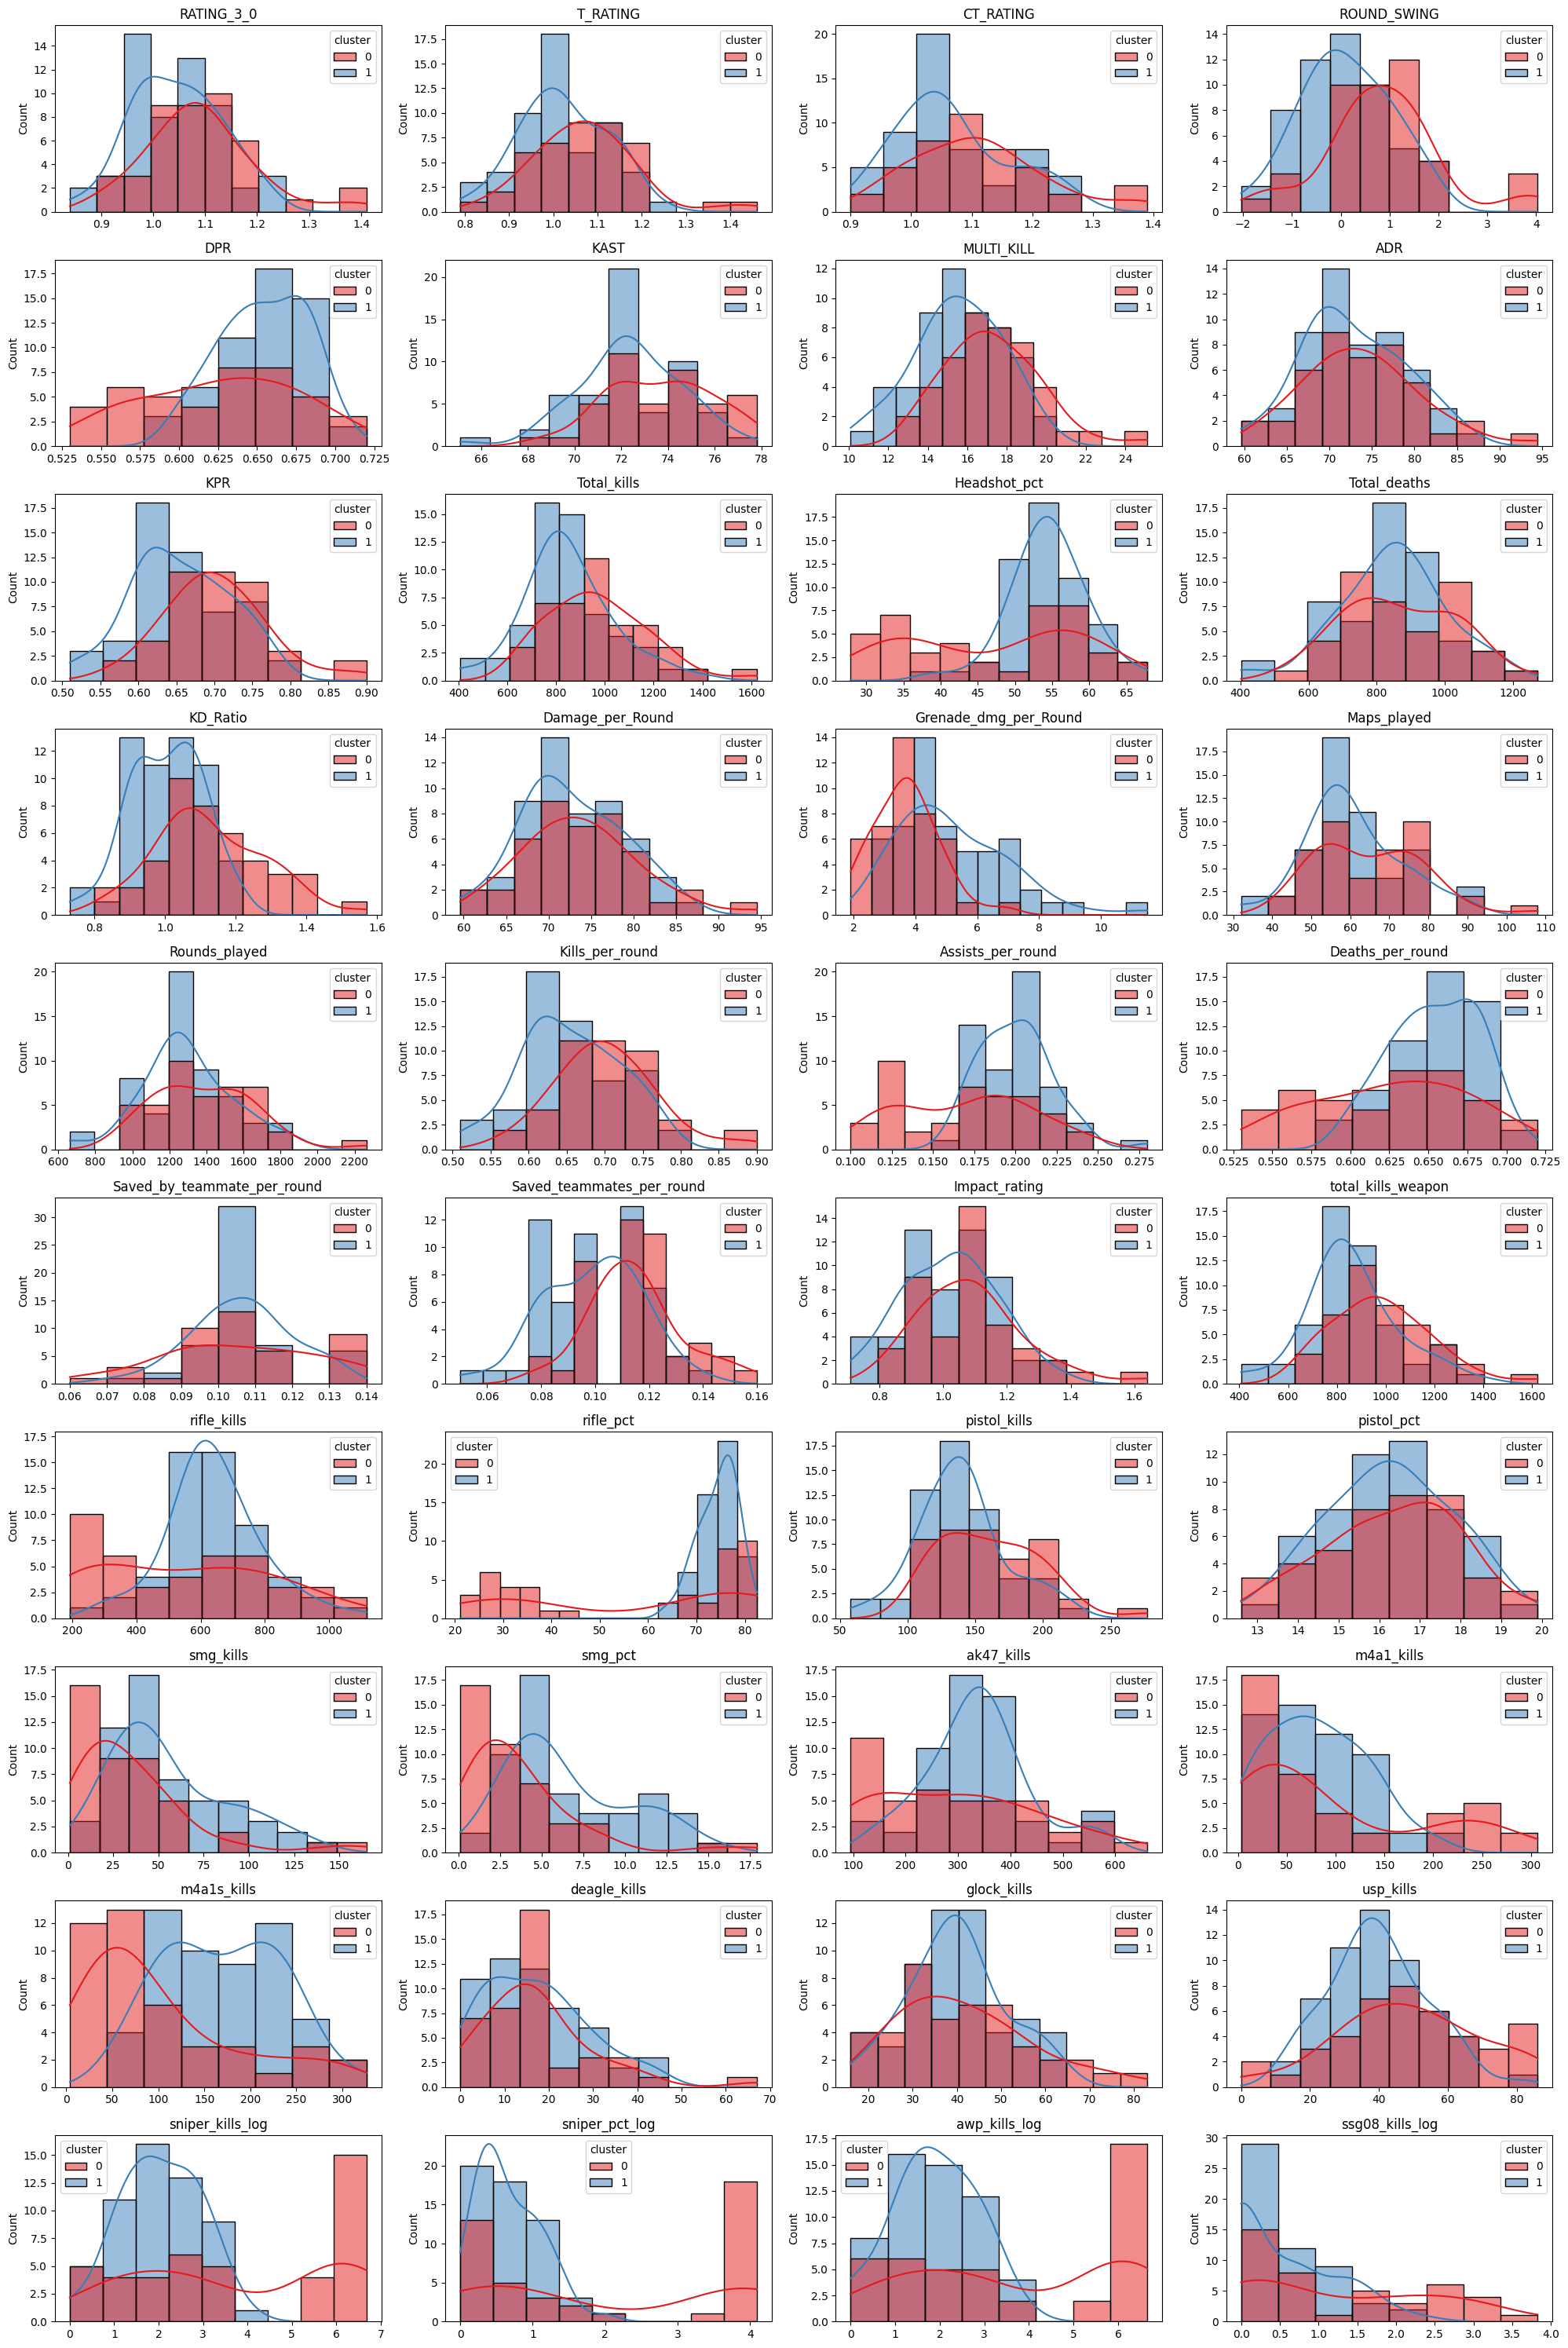

In [21]:
# Plot the distribution
n_cols = 4
n_rows = -(-len(feature_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df_labeled, x=col, hue='cluster', kde=True, ax=axes[i], palette='Set1')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()